In [1]:
from kaggle_environments import make

env = make('connectx')

rows = env.configuration.rows
columns = env.configuration.columns
inarow = env.configuration.inarow

assert rows == 6
assert columns == 7
assert inarow == 4

In [2]:
import torch
import numpy as np
import os

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

In [3]:
from types import SimpleNamespace
from my_dqn import My_DQN

device = 'cuda'
env_config = env.configuration
my_config = SimpleNamespace(
    h=128
)

Q_func = My_DQN(env_config, my_config, device)

In [4]:
Y = Q_func(torch.ones(5, 42, device=device))
print(Y)

tensor([[-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


---


Initialize replay memory $D$ to capacity $N$

Initialize action-value function $Q$ with random weights $\theta$

Initialize target action-value function $\hat{Q}$ with weights $\theta^- = \theta$

**For** episode $= 1, M$ **do**

$\quad$ Initialize sequence $s_1 = \{x_1\}$ and preprocessed sequence $\phi_1 = \phi(s_1)$

$\quad$ **For** $t = 1, T$ **do**

$\qquad$ With probability $\varepsilon$ select a random action $a_t$

$\qquad$ otherwise select $a_t = \text{argmax}_a Q(\phi(s_t), a; \theta)$

$\qquad$ Execute action $a_t$ in emulator and observe reward $r_t$ and image $x_{t+1}$

$\qquad$ Set $s_{t+1} = s_t, a_t, x_{t+1}$ and preprocess $\phi_{t+1} = \phi(s_{t+1})$

$\qquad$ Store transition $(\phi_t, a_t, r_t, \phi_{t+1})$ in $D$

$\qquad$ Sample random minibatch of transitions $(\phi_j, a_j, r_j, \phi_{j+1})$ from $D$

$\qquad$ Set $y_j = \begin{cases} r_j & \text{if episode terminates at step } j+1 \\ r_j + \gamma \max_{a'} \hat{Q}(\phi_{j+1}, a'; \theta^-) & \text{otherwise} \end{cases}$

$\qquad$ Perform a gradient descent step on $\left(y_j - Q(\phi_j, a_j; \theta)\right)^2$ with respect to the network parameters $\theta$

$\qquad$ Every $C$ steps reset $\hat{Q} = Q$

$\quad$ **End For**

**End For**

In [5]:
from op_agents.jekiwantaufik import jekiwantaufik


reward_for_inarow = torch.arange(inarow + 1, device=device) / inarow
reward_for_inarow[:2] = 0

train_config = SimpleNamespace(
    batch_size = 128,
    total_steps = 3000,
    epsilon = 0.1, # ???
    op_agents = ['random', 'negamax', jekiwantaufik],
    move_target_every = 100,

    validate_every = 1000,
    num_episodes = 100,
    val_op_agent = 'negamax',

    reward_for_None = -5,
    reward_for_inarow = reward_for_inarow,
    state_reward_coeff = 0.01
)

In [6]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

optimizer = AdamW(Q_func.parameters())
scheduler = LinearLR(
    optimizer, 
    start_factor=0.1, 
    end_factor=1, 
    total_iters=(train_config.total_steps - 2 * train_config.batch_size) / 2)

In [7]:
from train import train

logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, device=device)

| step: 100 |
| step: 200 |
| step: 300 | loss: 1.9454 |
| step: 400 | loss: 1.4645 |
| step: 500 | loss: 0.7807 |
| step: 600 | loss: 0.3445 |
| step: 700 | loss: 0.1337 |
| step: 800 | loss: 0.1474 |
| step: 900 | loss: 0.0943 |
| step: 1000 | loss: 0.3300 |
| step: 1000 | val_reward: -1.0000 |
| step: 1100 | loss: 0.2261 |
| step: 1200 | loss: 0.1102 |
| step: 1300 | loss: 0.1531 |
| step: 1400 | loss: 0.1817 |
| step: 1500 | loss: 0.2469 |
| step: 1600 | loss: 0.2325 |
| step: 1700 | loss: 0.3567 |
| step: 1800 | loss: 0.4114 |
| step: 1900 | loss: 0.2056 |
| step: 2000 | loss: 0.2777 |
| step: 2000 | val_reward: -0.9100 |
| step: 2100 | loss: 0.2020 |
| step: 2200 | loss: 0.2224 |
| step: 2300 | loss: 0.2274 |
| step: 2400 | loss: 0.3296 |
| step: 2500 | loss: 0.3168 |
| step: 2600 | loss: 0.2377 |
| step: 2700 | loss: 0.1714 |
| step: 2800 | loss: 0.1817 |
| step: 2900 | loss: 0.2075 |
| step: 3000 | loss: 0.2287 |
| step: 3000 | val_reward: -0.9600 |


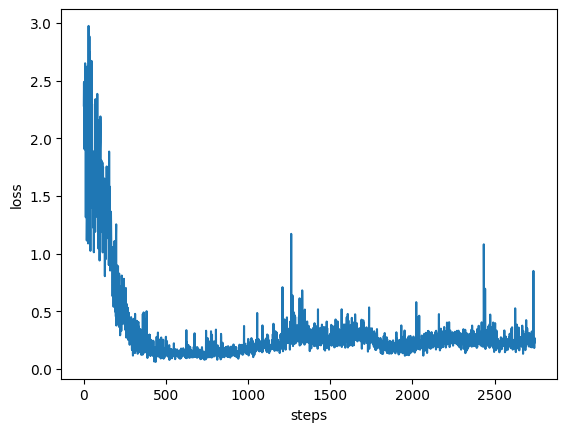

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=range(len(logs['loss'])), y=logs['loss'])
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

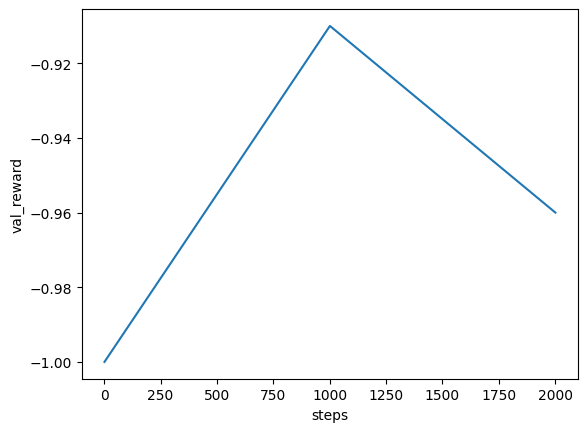

In [9]:
sns.lineplot(
    x=range(1, train_config.total_steps + 1, train_config.validate_every), 
    y=logs['val_reward']
)
plt.xlabel('steps')
plt.ylabel('val_reward')
plt.show()

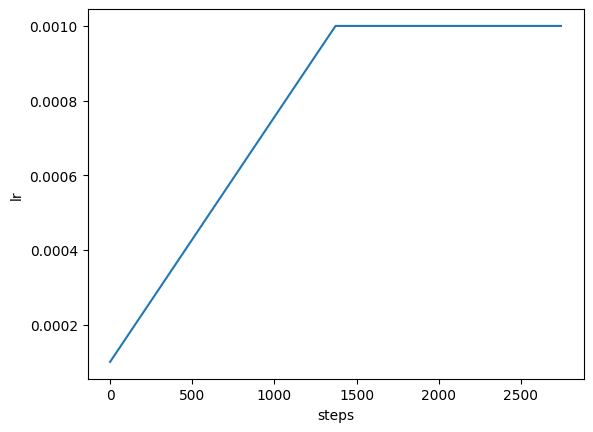

In [10]:
sns.lineplot(x=range(len(logs['lr'])), y=logs['lr'])
plt.xlabel('steps')
plt.ylabel('lr')
plt.show()